In [26]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

# test
B, T = 2, 64000
test_audio = torch.randn(B, 1, T)
print('test audio shape:', test_audio.shape)  

test audio shape: torch.Size([2, 1, 64000])


after PQMF (analysis): torch.Size([2, 32, 2000])
after PQMF (synthesis): torch.Size([2, 1, 63969])


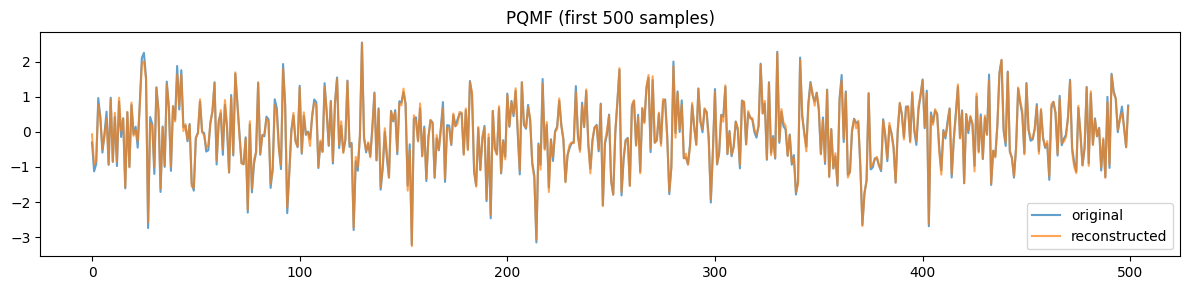

In [ ]:
from scipy.signal import kaiserord, firwin

def kaiser_filter(cutoff, attenuation, n_bands):
    
    ripple = attenuation
  
    width = 0.1 / n_bands
    # Use kaiserord to determine filter order n and Kaiser window beta parameter
    n, beta = kaiserord(ripple, width)
    # Ensure odd filter length for linear phase
    if n % 2 == 0:
        n += 1
    # use firwin with Kaiser window
    h = firwin(n, cutoff, window=('kaiser', beta))
    return h.astype(np.float32)

def qmf_bank(h, n_bands):
    n = len(h)
    k = np.arange(n_bands)[:, None]
    t = np.arange(n)[None, :]
    phase = np.pi / n_bands * (k + 0.5) * (t - (n - 1) / 2) + np.pi / 4 * (-1) ** k
    return (2 * h[None, :] * np.cos(phase)).astype(np.float32)

class PQMF(nn.Module):
    def __init__(self, n_bands=32, attenuation=100.0):
        super().__init__()
        self.n_bands = n_bands
        h = kaiser_filter(1.0 / (2 * n_bands), attenuation, n_bands)
        bank = qmf_bank(h, n_bands)
        analysis  = torch.from_numpy(bank).unsqueeze(1)
        synthesis = torch.from_numpy(bank).unsqueeze(1)
        self.register_buffer('analysis_filters',  analysis)
        self.register_buffer('synthesis_filters', synthesis)
        self.filter_len = bank.shape[-1]
        self.pad = self.filter_len // 2

    def forward(self, x):
        x = F.pad(x, (self.pad, self.pad))
        return F.conv1d(x, self.analysis_filters, stride=self.n_bands)

    def inverse(self, x):
        out = F.conv_transpose1d(x, self.synthesis_filters, stride=self.n_bands)
        out = out[..., self.pad: -self.pad if self.pad > 0 else None]
        return out * self.n_bands

# test
pqmf = PQMF(n_bands=32)

x_mb = pqmf(test_audio)
print('after PQMF (analysis):', x_mb.shape)   # (2, 32, 2000)

x_recon = pqmf.inverse(x_mb)
print('after PQMF (synthesis):', x_recon.shape)

plt.figure(figsize=(12, 3))
plt.plot(test_audio[0, 0, :500].numpy(), label='original', alpha=0.7)
plt.plot(x_recon[0, 0, :500].detach().numpy(), label='reconstructed', alpha=0.7)
plt.title('PQMF (first 500 samples)')
plt.legend()
plt.tight_layout()
plt.show()


In [28]:
class DilatedResidualBlock(nn.Module):
    def __init__(self, channels, kernel_size, dilation):
        super().__init__()
        pad = (kernel_size - 1) * dilation // 2
        self.net = nn.Sequential(
            nn.LeakyReLU(0.2),
            nn.Conv1d(channels, channels, kernel_size, dilation=dilation, padding=pad),
            nn.LeakyReLU(0.2),
            nn.Conv1d(channels, channels, 1),  
        )

    def forward(self, x):
        return x + self.net(x) 

block = DilatedResidualBlock(channels=64, kernel_size=3, dilation=3)
test_in = torch.randn(2, 64, 4096)
test_out = block(test_in)
print('DilatedResidualBlock — in:', test_in.shape, 'out:', test_out.shape)

DilatedResidualBlock — in: torch.Size([2, 64, 4096]) out: torch.Size([2, 64, 4096])


In [37]:
class DownsampleBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride, kernel_size=3, dilations=[1,3,9]):
        super().__init__()
        layers = []
        for d in dilations:
            layers.append(DilatedResidualBlock(in_channels, kernel_size, d))
        layers.append(nn.LeakyReLU(0.2))
        layers.append(nn.Conv1d(in_channels, out_channels,
                                kernel_size=2*stride, stride=stride, padding=stride//2))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

ds = DownsampleBlock(in_channels=64, out_channels=128, stride=4)
test_in = torch.randn(2, 64, 4096)
test_out = ds(test_in)
print('DownsampleBlock — in:', test_in.shape, 'out:', test_out.shape)
# expect (2, 128, 1024)

DownsampleBlock — in: torch.Size([2, 64, 4096]) out: torch.Size([2, 128, 1024])


In [ ]:
class Encoder(nn.Module):
    def __init__(self, in_channels=16, capacity=64, latent_size=128,
                 ratios=[4,4,4,2], kernel_size=3, dilations=[1,3,9]):
        super().__init__()
        self.stem = nn.Conv1d(in_channels, capacity, kernel_size=7, padding=3)

        #accumulate each DownsampleBlock layer
        stages, ch = [], capacity
        for r in ratios:
            stages.append(DownsampleBlock(ch, ch*2, stride=r,
                                          kernel_size=kernel_size, dilations=dilations))
            ch *= 2
        self.stages = nn.Sequential(*stages)

        self.head = nn.Sequential(
            nn.LeakyReLU(0.2),
            nn.Conv1d(ch, latent_size * 2, kernel_size=3, padding=1),
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.stages(x)
        return self.head(x)

# test
encoder = Encoder(in_channels=32, capacity=64, latent_size=128, ratios=[4,4,4,2])

x_mb   = pqmf(test_audio)    # (2, 32, 2000)
z_dist = encoder(x_mb)

print('PQMF output:    ', x_mb.shape)
print('Encoder output: ', z_dist.shape)

mean, logvar = z_dist.chunk(2, dim=1)
print('mean:   ', mean.shape)
print('logvar: ', logvar.shape)


PQMF output:     torch.Size([2, 32, 2000])
Encoder output:  torch.Size([2, 256, 15])
mean:    torch.Size([2, 128, 15])
logvar:  torch.Size([2, 128, 15])


In [38]:
class UpsampleBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride, kernel_size=3, dilations=[1,3,9]):
        super().__init__()
        layers = [
            nn.LeakyReLU(0.2),
            nn.ConvTranspose1d(in_channels, out_channels,
                               kernel_size=2*stride, stride=stride, padding=stride//2),
        ]
        for d in dilations:
            layers.append(DilatedResidualBlock(out_channels, kernel_size, d))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class Decoder(nn.Module):
    def __init__(self, out_channels=16, capacity=64, latent_size=128,
                 ratios=[4,4,4,2], kernel_size=3, dilations=[1,3,9]):
        super().__init__()
        n_stages = len(ratios)
        ch_start = capacity * (2 ** n_stages)

        self.stem = nn.Conv1d(latent_size, ch_start, kernel_size=3, padding=1)

        stages, ch = [], ch_start
        for r in reversed(ratios):
            stages.append(UpsampleBlock(ch, ch // 2, stride=r,
                                        kernel_size=kernel_size, dilations=dilations))
            ch //= 2
        self.stages = nn.Sequential(*stages)

        self.head = nn.Sequential(
            nn.LeakyReLU(0.2),
            nn.Conv1d(ch, out_channels, kernel_size=7, padding=3),
            nn.Tanh(),
        )

    def forward(self, z):
        x = self.stem(z)
        x = self.stages(x)
        return self.head(x)


# reparametrize using encoder mean/logvar from the cell above
logvar_c = logvar.clamp(-10, 4)
std = (0.5 * logvar_c).exp()
z = mean + torch.randn_like(std) * std

decoder = Decoder(out_channels=32, capacity=64, latent_size=128, ratios=[4,4,4,2])
x_mb_recon = decoder(z)

print('z shape:        ', z.shape)
print('Decoder output: ', x_mb_recon.shape)  # (2, 32, ~1920)


z shape:         torch.Size([2, 128, 16])
Decoder output:  torch.Size([2, 32, 2048])


Original length:      64000
Reconstructed length: 61409
Trimmed to:           61409


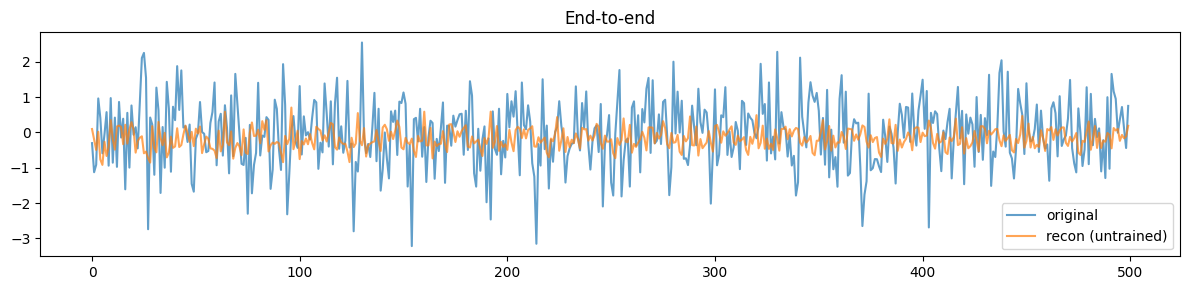

In [32]:
# Full PQMF synthesis -> reconstructed waveform
x_recon = pqmf.inverse(x_mb_recon)

min_len = min(test_audio.shape[-1], x_recon.shape[-1])
print(f'Original length:      {test_audio.shape[-1]}')
print(f'Reconstructed length: {x_recon.shape[-1]}')
print(f'Trimmed to:           {min_len}')

plt.figure(figsize=(12, 3))
plt.plot(test_audio[0, 0, :500].numpy(), label='original', alpha=0.7)
plt.plot(x_recon[0, 0, :500].detach().numpy(), label='recon (untrained)', alpha=0.7)
plt.title('End-to-end')
plt.legend()
plt.tight_layout()
plt.show()


Total loss
loss = Σ spectral_losses(x_real, x_recon)  +  beta × KL

In [ ]:
class VAELoss(nn.Module):
    def __init__(self, beta=1.0, fft_sizes=[2048, 1024, 512, 256, 128, 64]):
        super().__init__()
        self.beta     = beta
        self.spectral = nn.ModuleList([SpectralLoss(n, n // 4) for n in fft_sizes])

    def forward(self, x_real, x_recon, mean, logvar):
        recon = sum(s(x_real, x_recon) for s in self.spectral)
        # KL divergence: measures how far the encoder's learned distribution q(z|x) drifts from the prior p(z)=N(0,1).
        # Penalizes the latent space from collapsing into arbitrary clusters, keeping the model generative.
        #  -0.5 * (1 + logvar - mean² - exp(logvar))
        kl    = (-0.5 * (1 + logvar - mean.pow(2) - logvar.exp())).sum(1).mean()
        loss  = recon + self.beta * kl
        return {'loss': loss, 'recon': recon.detach(), 'kl': kl.detach()}

criterion = VAELoss(beta=1.0)
print('VAELoss ready — beta:', criterion.beta, '| spectral scales:', len(criterion.spectral))

VAELoss ready — beta: 1.0 | spectral scales: 6


Z = Mean + random sample from N(0,1) * Standard Deviation(scan the noise) 

In [34]:
class AudioVAE(nn.Module):
    def __init__(self, n_bands=16, latent_size=128, capacity=64,
                 ratios=[4,4,4,2], kernel_size=3, dilations=[1,3,9], beta=1.0):
        super().__init__()
        self.pqmf      = PQMF(n_bands=n_bands)
        self.encoder   = Encoder(n_bands, capacity, latent_size, ratios, kernel_size, dilations)
        self.decoder   = Decoder(n_bands, capacity, latent_size, ratios, kernel_size, dilations)
        self.criterion = VAELoss(beta=beta)
        self.beta      = beta

    def reparametrize(self, z_dist):
        mean, logvar = z_dist.chunk(2, dim=1)
        logvar = logvar.clamp(-10, 4)
        z = mean + (0.5 * logvar).exp() * torch.randn_like(logvar)
        return z, mean, logvar

    def encode(self, x):
        return self.reparametrize(self.encoder(self.pqmf(x)))

    def decode(self, z):
        return self.pqmf.inverse(self.decoder(z))

    def forward(self, x):
        z, _, _ = self.encode(x)
        return self.decode(z)

model = AudioVAE(n_bands=32, latent_size=128, capacity=64, ratios=[4,4,4,2], beta=1.0)
total = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nTrainable parameters: {total:,}')


AudioVAE(
  (pqmf): PQMF()
  (encoder): Encoder(
    (stem): Conv1d(32, 64, kernel_size=(7,), stride=(1,), padding=(3,))
    (stages): Sequential(
      (0): DownsampleBlock(
        (net): Sequential(
          (0): DilatedResidualBlock(
            (net): Sequential(
              (0): LeakyReLU(negative_slope=0.2)
              (1): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
              (2): LeakyReLU(negative_slope=0.2)
              (3): Conv1d(64, 64, kernel_size=(1,), stride=(1,))
            )
          )
          (1): DilatedResidualBlock(
            (net): Sequential(
              (0): LeakyReLU(negative_slope=0.2)
              (1): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(3,), dilation=(3,))
              (2): LeakyReLU(negative_slope=0.2)
              (3): Conv1d(64, 64, kernel_size=(1,), stride=(1,))
            )
          )
          (2): DilatedResidualBlock(
            (net): Sequential(
              (0): LeakyReLU(negative_slope

In [36]:
# Training step — forward, loss, backward, one optimizer step
torch.manual_seed(0)
x = torch.randn(2, 1, 65536)

model.train()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
optimizer.zero_grad()

z, mean, logvar = model.encode(x)
x_rec = model.decode(z)
min_len = min(x.shape[-1], x_rec.shape[-1])
losses = model.criterion(x[..., :min_len], x_rec[..., :min_len], mean, logvar)

losses['loss'].backward()

no_grad   = [n for n, p in model.named_parameters() if p.grad is None]
grad_norm = sum(p.grad.norm()**2 for p in model.parameters() if p.grad is not None).sqrt().item()

print(f"Recon loss:  {losses['recon'].item():.4f}")
print(f"KL loss:     {losses['kl'].item():.4f}")
print(f"Total loss:  {losses['loss'].item():.4f}")
print(f"Grad norm:   {grad_norm:.4f}")
print(f"No-grad params: {no_grad or 'none — all good'}")

optimizer.step()
print('\nOne optimizer step completed.')


Recon loss:  51.0385
KL loss:     0.1547
Total loss:  51.1932
Grad norm:   58.4841
No-grad params: none — all good

One optimizer step completed.
